Saving obj det.jpeg to obj det (1).jpeg


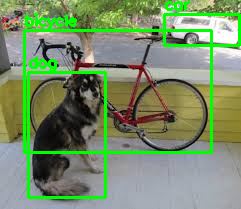

In [8]:
# Download YOLO files
!wget -q https://pjreddie.com/media/files/yolov3.weights -O yolov3.weights
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg -O yolov3.cfg
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names -O coco.names

import cv2, numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
img = cv2.imread(img_path)

# Load YOLO
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
classes = open("coco.names").read().strip().split("\n")
layer_names = net.getLayerNames()
out_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

# Detect
blob = cv2.dnn.blobFromImage(img, 1/255.0, (416,416), swapRB=True)
net.setInput(blob)
outs = net.forward(out_layers)

h, w = img.shape[:2]
boxes = []
confidences = []
class_ids = []

for out in outs:
    for det in out:
        scores = det[5:]
        cid = np.argmax(scores)
        conf = scores[cid]
        if conf > 0.5:
            cx, cy, bw, bh = det[:4] * np.array([w, h, w, h])
            x = int(cx - bw/2)
            y = int(cy - bh/2)
            boxes.append([x,y,int(bw),int(bh)])
            confidences.append(float(conf))
            class_ids.append(cid)

idxs = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

for i in idxs.flatten():
    x,y,bw,bh = boxes[i]
    label = classes[class_ids[i]]
    cv2.rectangle(img,(x,y),(x+bw,y+bh),(0,255,0),2)
    cv2.putText(img,label,(x,y-5),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

cv2_imshow(img)
